## Outliers in Data

Outliers are data points that **differ significantly** from the majority of the data. They can arise due to errors, variability in measurements, or genuine rare events.

### 1. What is an Outlier?

**Definition:**  
An outlier is an observation that lies **far away from other observations** in the dataset. It can be much higher, lower, or otherwise unusual compared to the rest of the data.

**Example:**

- In a dataset of human ages: `[25, 30, 28, 27, 150]` → `150` is an outlier.
- In income data: most incomes are between $40k–$120k, but a few entries are $1M → these are outliers.

### 2. Should We Remove Outliers?

It depends:

- **Remove or treat** if:

  - They are **data entry or measurement errors**.
  - They **distort statistical measures** like mean and standard deviation.

- **Keep** if:
  - They represent **valid rare events** (e.g., fraud detection, high-value sales).
  - The analysis or model can **handle extreme values** robustly.

### 3. Algorithms Sensitive to Outliers

Some machine learning models are **very sensitive** to outliers:

- **Linear regression** → outliers can skew coefficients.
- **K-Nearest Neighbors (KNN)** → distances are affected by extreme points.
- **Neural networks** → extreme values can affect loss and gradients.
- **Principal Component Analysis (PCA)** → directions of maximum variance can be dominated by outliers.

**Robust algorithms** are less sensitive:

- Tree-based models (Random Forest, XGBoost, Decision Trees)
- Median-based statistics instead of mean

### 4. Identifying Outliers

**Common methods:**

1. **Statistical methods:**

   - Z-score: $|\frac{x-\mu}{\sigma}| > 3$ often flagged as outlier
   - IQR (Interquartile Range):
     ```
     Q1 = 25th percentile
     Q3 = 75th percentile
     IQR = Q3 - Q1
     Lower Bound = Q1 - 1.5*IQR
     Upper Bound = Q3 + 1.5*IQR
     ```
   - Values outside [Lower Bound, Upper Bound] → outliers

2. **Visualization:**

   - Box plots
   - Scatter plots
   - Histograms

3. **Model-based detection:**
   - Isolation Forest
   - One-Class SVM
   - DBSCAN (clustering-based anomaly detection)

### 5. Handling Outliers

- **Remove them** (if they are errors)
- **Cap or floor values** (Winsorization)
- **Transform features**: log, square root, or Box-Cox
- **Use robust algorithms** that ignore extreme values

---


### Identify the Outliers

**z-score**


In [1]:
import pandas as pd
import numpy as np
from scipy import stats

data = pd.DataFrame({'Income': [40000, 45000, 42000, 200000, 47000, 43000, 41000]})
# Z-score
data['z_score'] = stats.zscore(data['Income'])
data['is_outlier'] = data['z_score'].abs() > 3
data

,Income,z_score,is_outlier
0,40000,-0.462483,False
1,45000,-0.371545,False
2,42000,-0.426108,False
3,200000,2.447521,False
4,47000,-0.335170,False
5,43000,-0.407920,False
6,41000,-0.444295,False


**Visualization**
Boxplots, scatter plots, histograms


<Axes: xlabel='Income'>

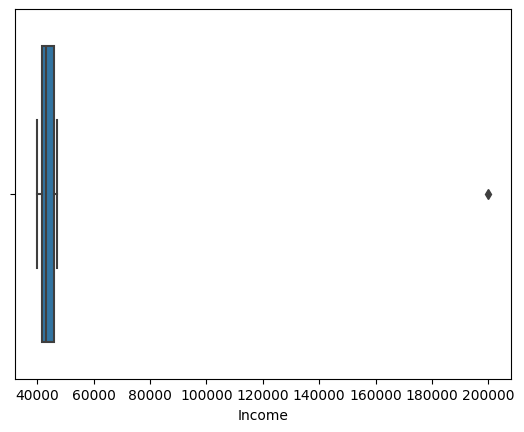

In [2]:
import seaborn as sns
sns.boxplot(x=data['Income'])

**Model-based detection:** Isolation Forest, One-Class SVM for multivariate outliers


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

np.random.seed(0)
data = pd.DataFrame({
    'Income': [40000, 45000, 42000, 500000, 47000, 43000, 41000, 60000, 58000, 1000000],
    'Age': [25, 30, 28, 35, 32, 31, 27, 29, 33, 40]
})

data

,Income,Age
0,40000,25
1,45000,30
2,42000,28
3,500000,35
4,47000,32
5,43000,31
6,41000,27
7,60000,29
8,58000,33
9,1000000,40


**Isolation Forest**

- `contamination` sets the expected fraction of outliers.


In [4]:
iso_forest = IsolationForest(contamination=0.1, random_state=42)
data['iso_outlier'] = iso_forest.fit_predict(data[['Income', 'Age']])
# Isolation Forest outputs: 1 = inlier, -1 = outlier
data['iso_outlier'] = data['iso_outlier'].map({1: False, -1: True})

print("\nIsolation Forest Outliers:\n", data)


Isolation Forest Outliers:
     Income  Age  iso_outlier
0    40000   25        False
1    45000   30        False
2    42000   28        False
3   500000   35        False
4    47000   32        False
5    43000   31        False
6    41000   27        False
7    60000   29        False
8    58000   33        False
9  1000000   40         True


**One-Class SVM**

- Treats the data as one class and finds a boundary for inliers.
- Points outside the boundary are flagged as outliers.


In [5]:
svm = OneClassSVM(nu=0.1, kernel='rbf', gamma=0.1)
svm.fit(data[['Income', 'Age']])
data['svm_outlier'] = svm.predict(data[['Income', 'Age']])
# One-Class SVM outputs: 1 = inlier, -1 = outlier
data['svm_outlier'] = data['svm_outlier'].map({1: False, -1: True})

print("\nOne-Class SVM Outliers:\n", data)


One-Class SVM Outliers:
     Income  Age  iso_outlier  svm_outlier
0    40000   25        False        False
1    45000   30        False         True
2    42000   28        False         True
3   500000   35        False        False
4    47000   32        False         True
5    43000   31        False         True
6    41000   27        False         True
7    60000   29        False         True
8    58000   33        False        False
9  1000000   40         True        False


Model-based outlier detection is not deterministic across different algorithms because each method has a different assumption about `normal` behavior in the data.

1. Isolation Forest

   - Assumption: Outliers are easier to isolate in the feature space.

   - Works well for high-dimensional or non-linear data.

   - Less sensitive to scaling if you use raw data.

   - Often used in industry for fraud detection, anomaly detection in logs, sensors.

2. One-Class SVM

   - Assumption: Data forms a single cluster, and outliers are outside the learned boundary.

   - Sensitive to feature scaling and kernel choice (rbf, linear).

   - Good for low-dimensional data with well-defined boundaries.

### Practical advice

- Always visualize outliers first (scatterplot, boxplot).

- If your data is high-dimensional and complex → Isolation Forest.

- If your data is low-dimensional and roughly clustered → One-Class SVM.

- If you want transparent reasoning for business decisions, use Z-score or IQR.
